![Co-learning Lounge](https://s3.ap-south-1.amazonaws.com/townscript-production/images/2545d2c7-a6e8-486e-97e6-737c42cef670.jpg)
Thanks to the Co-learning Lounge for pushing to create learning content on [PyCaret](https://pycaret.org/) with Kaggle playground problem.

You can find most updated and comprehensive learning material in their community.

Join and follow the [Co-learning Lounge](https://linktr.ee/colearninglounge) for more.

**Data Dictionary**:
* survival - Survival (0 = No; 1 = Yes)
* class - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)
* name - Name
* sex - Sex
* age - Age
* sibsp - Number of Siblings/Spouses Aboard
* parch - Number of Parents/Children Aboard
* ticket - Ticket Number
* fare - Passenger Fare
* cabin - Cabin
* embarked - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

## Import Libararies

In [1]:
import numpy as np # linear algebra
import pandas as pd 

Quickly let us get into the installation and build a perfect model.

In [2]:
!pip3 install pycaret

     |████████████████████████████████| 255 kB 188 kB/s eta 0:00:01
     |████████████████████████████████| 60 kB 582 kB/s eta 0:00:011
     |████████████████████████████████| 12.4 MB 5.1 MB/s eta 0:00:01
     |████████████████████████████████| 93 kB 797 kB/s eta 0:00:011
     |████████████████████████████████| 235 kB 8.0 MB/s eta 0:00:01
     |████████████████████████████████| 77 kB 3.8 MB/s eta 0:00:011
     |████████████████████████████████| 49 kB 3.8 MB/s  eta 0:00:01
     |████████████████████████████████| 326 kB 7.3 MB/s eta 0:00:01
     |████████████████████████████████| 6.0 MB 7.9 MB/s eta 0:00:01


     |████████████████████████████████| 2.1 MB 10.5 MB/s eta 0:00:01
     |████████████████████████████████| 121 kB 11.0 MB/s eta 0:00:01
     |████████████████████████████████| 84 kB 2.1 MB/s  eta 0:00:01


     |████████████████████████████████| 45 kB 2.2 MB/s  eta 0:00:01
  Created wheel for pyod: filename=pyod-0.8.1-py3-none-any.whl size=105651 sha256=8a71f017e78c7fe0d2bd510cfcf425acd5b8b3ccb4f25bf415dbd2683997625f
  Stored in directory: /root/.cache/pip/wheels/d6/f2/24/2c050361bd259bee34bbef8047bbcd3f08085f2a8a5ed1fc85
  Created wheel for prometheus-flask-exporter: filename=prometheus_flask_exporter-0.15.4-py3-none-any.whl size=16451 sha256=a586b8fd9577823d4737f6409cd63c9da9377038dc1ae7753952a7749f002c1a
  Stored in directory: /root/.cache/pip/wheels/69/e3/ab/f10afded2fa6225f1672b34a7438cadf596e359a21f454d22c
  Created wheel for databricks-cli: filename=databricks_cli-0.11.0-py3-none-any.whl size=90300 sha256=2738784c5ad4b58f039848c5a9c98416f4549fc355a7fdc8c8924724875d50a4
  Stored in directory: /root/.cache/pip/wheels/81/3f/18/5678c9d403583e583a251463196998b17852b98de34aa9ab51
  Created wheel for sqlalchemy: filename=SQLAlchemy-1.3.13-cp37-cp37m-linux_x86_64.whl size=1221860 sha256=8

You should consider upgrading via the '/opt/conda/bin/python3.7 -m pip install --upgrade pip' command.


In [3]:
train = pd.read_csv("/kaggle/input/titanic/train.csv")
test = pd.read_csv("/kaggle/input/titanic/test.csv")

**Setup**

* Setup() performs inferences about the data and creates the transformation pipeline to prepare the data for modeling and deployment. 
* Initializing setup() function performs some basic preprocessing tasks like ignoring the IDs and Date Columns, imputing the missing values, encoding the categorical variables, and splitting the dataset into the train-test split, data imbalance, feature selection, binning, etc. for the rest of the modeling steps. When you run the setup function, it will first confirm the data types, and then if you press enter, it will create an environment for data preprocessing.
* It takes 2 mendatory parameter Dataframe and name of the target column


In [4]:
from pycaret import classification
classification_setup = classification.setup(data=train,target='Survived', ignore_features = ['Ticket', 'Name', 'PassengerId'], silent = True, session_id=42)

Setup Succesfully Completed!


,Description,Value
0,session_id,42
1,Target Type,Binary
2,Label Encoded,None
3,Original Data,"(891, 12)"
4,Missing Values,True
5,Numeric Features,3
6,Categorical Features,8
7,Ordinal Features,False
8,High Cardinality Features,False
9,High Cardinality Method,None


So, now the necessary preprocessing is done, let’s create a classification model. 

**Compare Models**

* Compare_models function train all the models which are available in library using stratified cross validation, this function will return score grid of all model across k-fold(default=10).
* Scoring matrics used are Accuracy, AUC, Recall, Precision, F1, Kappa and MCC. Mean and standard deviation of the scores across the folds are also returned.
* You can blacklist(omit certain models from the comparison) and whiltelist(un only certain models for the comparison) the model, passig model ID’s as a list of strings
eg. whitelist = compare_models(whitelist = ['dt','rf','xgboost'])
blacklist = compare_models(blacklist = ['catboost', 'svm'])
* Best model return as per the sort parameter(default=Accuracy) passed.
* Also we can select N top models passing n_select(default=1) parameter

In [5]:
classification.compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Light Gradient Boosting Machine,0.8235,0.8648,0.7366,0.7944,0.7616,0.6221,0.6257,0.0461
1,CatBoost Classifier,0.8203,0.8674,0.6909,0.8179,0.7452,0.6086,0.6169,1.4486
2,Gradient Boosting Classifier,0.8123,0.8657,0.6991,0.7923,0.7395,0.5942,0.5998,0.1925
3,Ridge Classifier,0.8107,0.0000,0.7116,0.7792,0.7414,0.5930,0.5967,0.0137
4,Logistic Regression,0.8074,0.8521,0.7199,0.7715,0.7401,0.5881,0.5932,0.0544
5,Linear Discriminant Analysis,0.8026,0.8446,0.7033,0.7661,0.7306,0.5759,0.5796,0.0229
6,Extreme Gradient Boosting,0.7899,0.8451,0.7033,0.7434,0.7192,0.5520,0.5556,0.5141
7,Ada Boost Classifier,0.7864,0.8209,0.7370,0.7197,0.7254,0.5514,0.5545,0.1524
8,Random Forest Classifier,0.7835,0.8368,0.6786,0.7439,0.7030,0.5345,0.5413,0.1141
9,Extra Trees Classifier,0.7804,0.8271,0.6618,0.7446,0.6947,0.5252,0.5321,0.2725


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, silent=True,
               subsample=1.0, subsample_for_bin=200000, subsample_freq=0)

In [6]:
from pycaret.classification import *
models()
compare_models(whitelist = models(type='ensemble').index.tolist())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
0,Light Gradient Boosting Machine,0.8235,0.8648,0.7366,0.7944,0.7616,0.6221,0.6257,0.0408
1,CatBoost Classifier,0.8203,0.8674,0.6909,0.8179,0.7452,0.6086,0.6169,1.5726
2,Gradient Boosting Classifier,0.8123,0.8657,0.6991,0.7923,0.7395,0.5942,0.5998,0.1899
3,Extreme Gradient Boosting,0.7899,0.8451,0.7033,0.7434,0.7192,0.5520,0.5556,0.4687
4,Ada Boost Classifier,0.7864,0.8209,0.7370,0.7197,0.7254,0.5514,0.5545,0.1412
5,Random Forest Classifier,0.7835,0.8368,0.6786,0.7439,0.7030,0.5345,0.5413,0.1158
6,Extra Trees Classifier,0.7804,0.8271,0.6618,0.7446,0.6947,0.5252,0.5321,0.2715


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, silent=True,
               subsample=1.0, subsample_for_bin=200000, subsample_freq=0)

This returns you pandas dataframe with all ready-to-use models available in the library.

Just a functional execution call, and it will compare all the classification models with few seconds and display the sorted score grid.

Note: It seems that the Ridge classifier gives higher accuracy than the rest classifier.

**Create Model**

* Let’s create an individual model that displays different evaluation matric using 10 k-fold with mean and std.
* create_model function takes just the one parameter – the model abbreviation as a string.

In [7]:
lgb_classifier = classification.create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9049,0.7917,0.9048,0.8444,0.7586,0.7627
1,0.7778,0.8472,0.5833,0.7778,0.6667,0.5051,0.5168
2,0.7937,0.8339,0.7083,0.7391,0.7234,0.5590,0.5593
3,0.7903,0.9208,0.7826,0.6923,0.7347,0.5624,0.5653
4,0.8387,0.8805,0.6667,0.8889,0.7619,0.6437,0.6589
5,0.8871,0.8958,0.8333,0.8696,0.8511,0.7602,0.7607
6,0.8548,0.9024,0.7917,0.8261,0.8085,0.6917,0.6921
7,0.7581,0.7544,0.6667,0.6957,0.6809,0.4862,0.4865
8,0.8871,0.8914,0.8333,0.8696,0.8511,0.7602,0.7607
9,0.7581,0.8169,0.7083,0.6800,0.6939,0.4940,0.4943


* Above score grid, shows the result of the model at each iteration and provide mean and std of it.

**Hyperparameter Tuning**

* Depending on the model evaluation metric(s) we are interested in pycaret helps us to straightaway zoom in on the top-performing model which we can further tune using the hyper-parameters.
* tune_model() function tune the hyperparameters of a model and it takes one parameter model abbreviation string (same as we used for creating model)

In [27]:
params = {'learning_rate':[0.15,0.1,0.05,0.01,0.005,0.001],
          'n_estimators':[100,250,500,750,1000,1250,1500,1750],
          'max_depth': np.random.randint(1, (len(train.columns)*.85),20),
          'max_features': np.random.randint(1, len(train.columns),20),
          'min_samples_split':[2,4,6,8,10,20,40,60,100], 
          'min_samples_leaf':[1,3,5,7,9],
          'criterion': ["gini", "entropy"]}

tune_lgb = classification.tune_model(lgb_classifier, custom_grid = params)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8889,0.9209,0.7917,0.9048,0.8444,0.7586,0.7627
1,0.7778,0.8697,0.6667,0.7273,0.6957,0.5212,0.5224
2,0.7778,0.8264,0.5833,0.7778,0.6667,0.5051,0.5168
3,0.7742,0.8941,0.7826,0.6667,0.7200,0.5328,0.5376
4,0.8065,0.8328,0.6250,0.8333,0.7143,0.5724,0.5860
5,0.9194,0.9249,0.8750,0.9130,0.8936,0.8287,0.8292
6,0.8710,0.9079,0.7500,0.9000,0.8182,0.7195,0.7266
7,0.7581,0.7730,0.6667,0.6957,0.6809,0.4862,0.4865
8,0.8871,0.9145,0.8333,0.8696,0.8511,0.7602,0.7607
9,0.8065,0.8257,0.7500,0.7500,0.7500,0.5921,0.5921


In [29]:
# Tune the model
params = {'alpha':[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]}
tune_ridge = classification.tune_model(create_model('ridge'), custom_grid = params, n_iter=50, fold=50)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7692,0.0000,0.8000,0.6667,0.7273,0.5301,0.5367
1,0.8462,0.0000,0.6000,1.0000,0.7500,0.6486,0.6928
2,0.7692,0.0000,0.6000,0.7500,0.6667,0.4935,0.5007
3,0.7692,0.0000,1.0000,0.6250,0.7692,0.5618,0.6250
4,0.6923,0.0000,0.4000,0.6667,0.5000,0.2973,0.3175
5,0.6923,0.0000,0.6000,0.6000,0.6000,0.3500,0.3500
6,0.8462,0.0000,0.8000,0.8000,0.8000,0.6750,0.6750
7,0.8462,0.0000,0.8000,0.8000,0.8000,0.6750,0.6750
8,0.9231,0.0000,1.0000,0.8333,0.9091,0.8434,0.8539
9,0.8462,0.0000,0.6000,1.0000,0.7500,0.6486,0.6928


In PyCaret, we can create bagging, boosting, blending, and stacking ensemble models with just one line of code.

**Ensemble Model**

In [31]:
# ensemble boosting
bagging = classification.ensemble_model(tune_lgb, method= 'Bagging')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8730,0.9295,0.7917,0.8636,0.8261,0.7264,0.7281
1,0.7619,0.8782,0.6250,0.7143,0.6667,0.4828,0.4854
2,0.7937,0.8435,0.6250,0.7895,0.6977,0.5442,0.5528
3,0.8065,0.9231,0.7826,0.7200,0.7500,0.5926,0.5939
4,0.7903,0.8586,0.6250,0.7895,0.6977,0.5405,0.5491
5,0.9032,0.9178,0.8333,0.9091,0.8696,0.7929,0.7948
6,0.8710,0.9013,0.7500,0.9000,0.8182,0.7195,0.7266
7,0.7903,0.7632,0.6250,0.7895,0.6977,0.5405,0.5491
8,0.8871,0.9090,0.8333,0.8696,0.8511,0.7602,0.7607
9,0.7903,0.8246,0.6667,0.7619,0.7111,0.5477,0.5507


**Blend Models**

Combining different machine learning models and use a majority vote or the average predicted probabilities in case of classification to predict the final outcome.

In [32]:
from pycaret.classification import blend_models
# blending all models
blend_all = blend_models(method='hard')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8254,0.0000,0.7917,0.7600,0.7755,0.6328,0.6331
1,0.7778,0.0000,0.5000,0.8571,0.6316,0.4878,0.5241
2,0.7460,0.0000,0.5833,0.7000,0.6364,0.4437,0.4481
3,0.8710,0.0000,0.8261,0.8261,0.8261,0.7235,0.7235
4,0.8065,0.0000,0.5417,0.9286,0.6842,0.5582,0.6004
5,0.9032,0.0000,0.8333,0.9091,0.8696,0.7929,0.7948
6,0.7903,0.0000,0.6250,0.7895,0.6977,0.5405,0.5491
7,0.8226,0.0000,0.6667,0.8421,0.7442,0.6112,0.6209
8,0.8871,0.0000,0.8333,0.8696,0.8511,0.7602,0.7607
9,0.7419,0.0000,0.6250,0.6818,0.6522,0.4477,0.4487


**Stack Models**

Stacking is an ensembling method that uses meta-learning. The idea behind stacking is to build a meta-model that generates the final prediction using the prediction of multiple base estimators.

In [33]:
# create individual models for stacking
ridge_cls = classification.create_model('ridge')
extre_tr = classification.create_model('et')
lgb = classification.create_model('lightgbm')
cat_cls = classification.create_model('catboost')
lg_cls = classification.create_model('lr')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.7937,0.8835,0.7917,0.7037,0.7451,0.5728,0.5756
1,0.8413,0.8697,0.7917,0.7917,0.7917,0.6635,0.6635
2,0.7619,0.8499,0.6667,0.6957,0.6809,0.4911,0.4914
3,0.8226,0.9030,0.7826,0.7500,0.7660,0.6232,0.6236
4,0.7903,0.8300,0.5833,0.8235,0.6829,0.5330,0.5507
5,0.8710,0.9145,0.8333,0.8333,0.8333,0.7281,0.7281
6,0.7903,0.8761,0.6250,0.7895,0.6977,0.5405,0.5491
7,0.8226,0.7950,0.6250,0.8824,0.7317,0.6049,0.6249
8,0.8387,0.8421,0.7917,0.7917,0.7917,0.6601,0.6601
9,0.7419,0.7577,0.7083,0.6538,0.6800,0.4644,0.4654


In [34]:
from pycaret.classification import stack_models
# stacking models
stacker = stack_models(estimator_list = [ridge_cls, extre_tr, lgb, cat_cls, lg_cls],method='hard')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8254,0.9060,0.7917,0.7600,0.7755,0.6328,0.6331
1,0.7937,0.8782,0.6250,0.7895,0.6977,0.5442,0.5528
2,0.7778,0.8339,0.6667,0.7273,0.6957,0.5212,0.5224
3,0.7903,0.8986,0.7826,0.6923,0.7347,0.5624,0.5653
4,0.8387,0.8289,0.6667,0.8889,0.7619,0.6437,0.6589
5,0.9032,0.9068,0.8333,0.9091,0.8696,0.7929,0.7948
6,0.8226,0.9101,0.7083,0.8095,0.7556,0.6173,0.6207
7,0.8226,0.7906,0.6667,0.8421,0.7442,0.6112,0.6209
8,0.8871,0.8607,0.8333,0.8696,0.8511,0.7602,0.7607
9,0.7258,0.7829,0.6667,0.6400,0.6531,0.4266,0.4268


**Plot Model**
Pycaret also evaluate your model performance as easy as you build the model with different plots

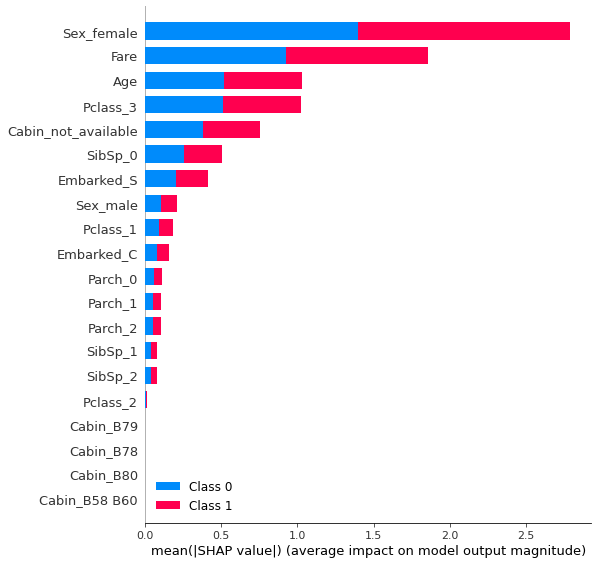

In [35]:
interpret_model(tune_lgb)

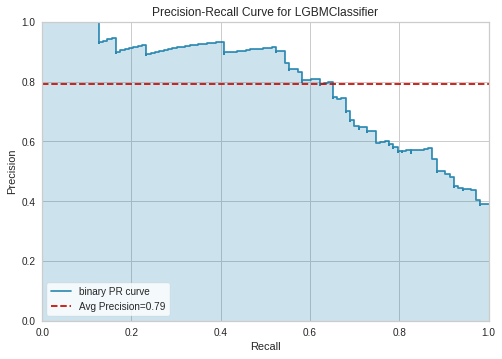

In [37]:
from pycaret.classification import *
# plotting a model
plot_model(tune_lgb,plot = 'pr')

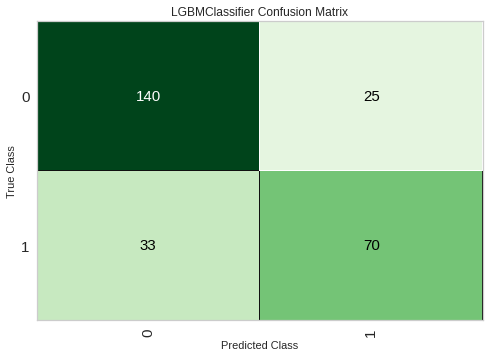

In [38]:
# plotting a model
plot_model(tune_lgb,plot = 'confusion_matrix')

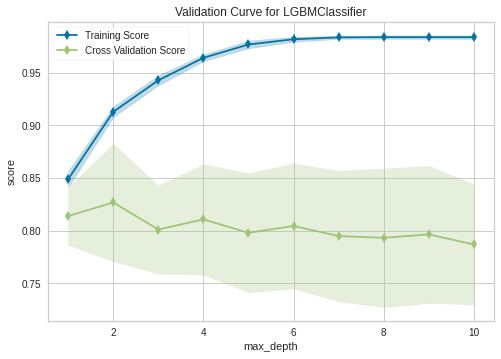

In [39]:
# Validation Curve
plot_model(tune_lgb, plot = 'vc')`

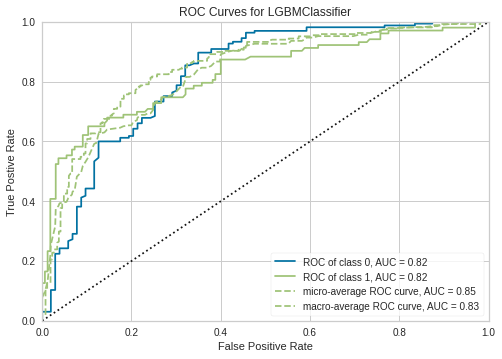

In [41]:
# AUC Curve
plot_model(tune_lgb, plot = 'auc')

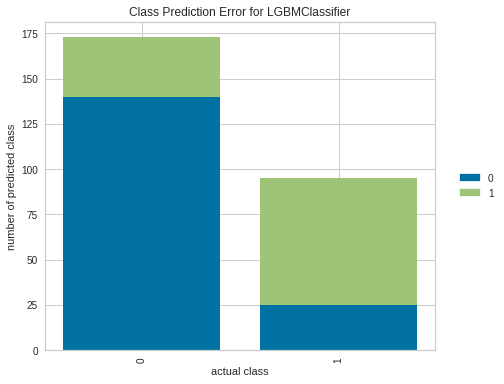

In [42]:
# error Curve
plot_model(tune_lgb, plot = 'error')

**Prediction**

In [43]:
y_pred = predict_model(tune_lgb, data=test)

In [44]:
y_pred

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Label,Score
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,0.1098
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,0,0.0008
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,0.0255
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,0.0659
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,0,0.3278
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,0,0.0905
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,1,0.9980
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,0,0.0019
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,0,0.0905


In [45]:
submission = pd.DataFrame({
        "PassengerId": test["PassengerId"],
        "Survived": y_pred['Label']
    })
submission.to_csv("submission.csv", index=False)